# Error Analysis
Using the best model we have achieved so far, we can see the mistakes it is making on the final test set

In [1]:
import os

if os.getcwd().split('/')[-1] == 'notebooks' or os.getcwd().split('\\')[-1] == 'notebooks':
    os.chdir('..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

# PyTorch & Transformers Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Preparation and Label Consolidation

In [3]:
print("\n" + "="*80)
print("1. DATA LOADING & PREPARATION")
print("="*80)

# MAPEO OFICIAL
EVASION_LABELS = {
    0: 'Claims ignorance', 1: 'Clarification', 2: 'Declining to answer',
    3: 'Deflection', 4: 'Dodging', 5: 'Explicit',
    6: 'General', 7: 'Implicit', 8: 'Partial/half-answer'
}
LABEL2ID = {v: k for k, v in EVASION_LABELS.items()}
label_names = [EVASION_LABELS[i] for i in sorted(EVASION_LABELS.keys())]

# Cargar dataset
ds = load_dataset("ailsntua/QEvasion")
train_df = ds['train'].to_pandas()
test_set_raw = ds['test']

# --- CORRECCIÓN 1: BLINDAR Y_TRAIN ---
# Verificar si train_df['evasion_label'] es texto y convertirlo si es necesario
if train_df['evasion_label'].dtype == 'O' or isinstance(train_df['evasion_label'].iloc[0], str):
    print("Detected string labels in Train set. Converting to IDs...")
    train_df['evasion_label'] = train_df['evasion_label'].map(LABEL2ID)

train_df['evasion_label'] = train_df['evasion_label'].astype(int)
print("Train labels type checked: IDs (int)")

# Función de Voto por Mayoría
def consolidate_labels(example):
    votes = [example['annotator1'], example['annotator2'], example['annotator3']]
    counts = Counter(votes)
    most_common = counts.most_common()
    if most_common[0][1] > 1:
        final_label_txt = most_common[0][0]
    else:
        final_label_txt = random.choice(votes)
    return {'evasion_label_txt': final_label_txt}

# Procesar Test Set
print("Consolidating Test Set Labels...")
test_set_processed = test_set_raw.map(consolidate_labels)
test_df = test_set_processed.to_pandas()

# --- CORRECCIÓN 2: BLINDAR Y_TEST ---
print("Mapping Test Labels to Numeric IDs...")
# Asegurarnos de limpiar espacios en blanco por si acaso
test_df['evasion_label_txt'] = test_df['evasion_label_txt'].str.strip()
test_df['evasion_label'] = test_df['evasion_label_txt'].map(LABEL2ID)

# Eliminar errores de mapeo
if test_df['evasion_label'].isnull().any():
    n_dropped = test_df['evasion_label'].isnull().sum()
    print(f"Warning: Dropping {n_dropped} rows with unmapped labels.")
    test_df = test_df.dropna(subset=['evasion_label'])

test_df['evasion_label'] = test_df['evasion_label'].astype(int)

# Context Features
for df in [train_df, test_df]:
    df['sub_q_context'] = df['question'].fillna('') + " [SEP] " + df['interview_answer'].fillna('')

print(f"Final Train size: {len(train_df)}")
print(f"Final Test size:  {len(test_df)}")


1. DATA LOADING & PREPARATION


Detected string labels in Train set. Converting to IDs...
Train labels type checked: IDs (int)
Consolidating Test Set Labels...


Map:   0%|          | 0/308 [00:00<?, ? examples/s]

Mapping Test Labels to Numeric IDs...
Final Train size: 3448
Final Test size:  308


## Model Training

In [4]:
print("\n" + "="*80)
print("2. TRAINING BEST MODEL (RoBERTa - Custom Loop)")
print("="*80)

# Hyperparameters
BEST_LR = 2e-5
BEST_BATCH_SIZE = 16
EPOCHS = 20
MAX_LEN = 128
MODEL_ID = "roberta-base"
NUM_CLASSES = len(EVASION_LABELS)

# Dataset Class
class EvasionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

print("Loading tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=NUM_CLASSES).to(device)

print("Preparing DataLoaders...")
train_dataset = EvasionDataset(train_df["sub_q_context"], train_df["evasion_label"], tokenizer, max_length=MAX_LEN)
test_dataset = EvasionDataset(test_df["sub_q_context"], test_df["evasion_label"], tokenizer, max_length=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=BEST_LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

print(f"Training for {EPOCHS} epochs...")
t0_train = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        
    print(f"  [RoBERTa] Epoch {epoch+1}/{EPOCHS} | Loss = {total_loss/len(train_loader):.4f}")

print(f"Training Complete in {time.time() - t0_train:.1f}s")

print("Predicting on Test Set...")
model.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        preds = model(**batch).logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())

# Format predictions to match the rest of your notebook
y_pred = np.array(all_preds)
y_test = test_df['evasion_label'].values 


2. TRAINING BEST MODEL (RoBERTa - Custom Loop)
Loading tokenizer and model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Preparing DataLoaders...
Training for 20 epochs...
  [RoBERTa] Epoch 1/20 | Loss = 1.9939
  [RoBERTa] Epoch 2/20 | Loss = 1.7980
  [RoBERTa] Epoch 3/20 | Loss = 1.6031
  [RoBERTa] Epoch 4/20 | Loss = 1.4061
  [RoBERTa] Epoch 5/20 | Loss = 1.1605
  [RoBERTa] Epoch 6/20 | Loss = 0.9326
  [RoBERTa] Epoch 7/20 | Loss = 0.7578
  [RoBERTa] Epoch 8/20 | Loss = 0.5642
  [RoBERTa] Epoch 9/20 | Loss = 0.4170
  [RoBERTa] Epoch 10/20 | Loss = 0.3105
  [RoBERTa] Epoch 11/20 | Loss = 0.2521
  [RoBERTa] Epoch 12/20 | Loss = 0.1914
  [RoBERTa] Epoch 13/20 | Loss = 0.1486
  [RoBERTa] Epoch 14/20 | Loss = 0.1268
  [RoBERTa] Epoch 15/20 | Loss = 0.1119
  [RoBERTa] Epoch 16/20 | Loss = 0.0900
  [RoBERTa] Epoch 17/20 | Loss = 0.0763
  [RoBERTa] Epoch 18/20 | Loss = 0.0653
  [RoBERTa] Epoch 19/20 | Loss = 0.0591
  [RoBERTa] Epoch 20/20 | Loss = 0.0511
Training Complete in 191.4s
Predicting on Test Set...


## Confusion Matrix


3. CONFUSION MATRIX
                     precision    recall  f1-score   support

   Claims ignorance       0.67      0.50      0.57         8
      Clarification       0.67      0.50      0.57         4
Declining to answer       0.27      0.31      0.29        13
         Deflection       0.10      0.14      0.12        22
            Dodging       0.38      0.28      0.32        54
           Explicit       0.48      0.51      0.49        83
            General       0.29      0.19      0.23        57
           Implicit       0.25      0.31      0.28        62
Partial/half-answer       0.00      0.00      0.00         5

           accuracy                           0.32       308
          macro avg       0.34      0.30      0.32       308
       weighted avg       0.34      0.32      0.33       308



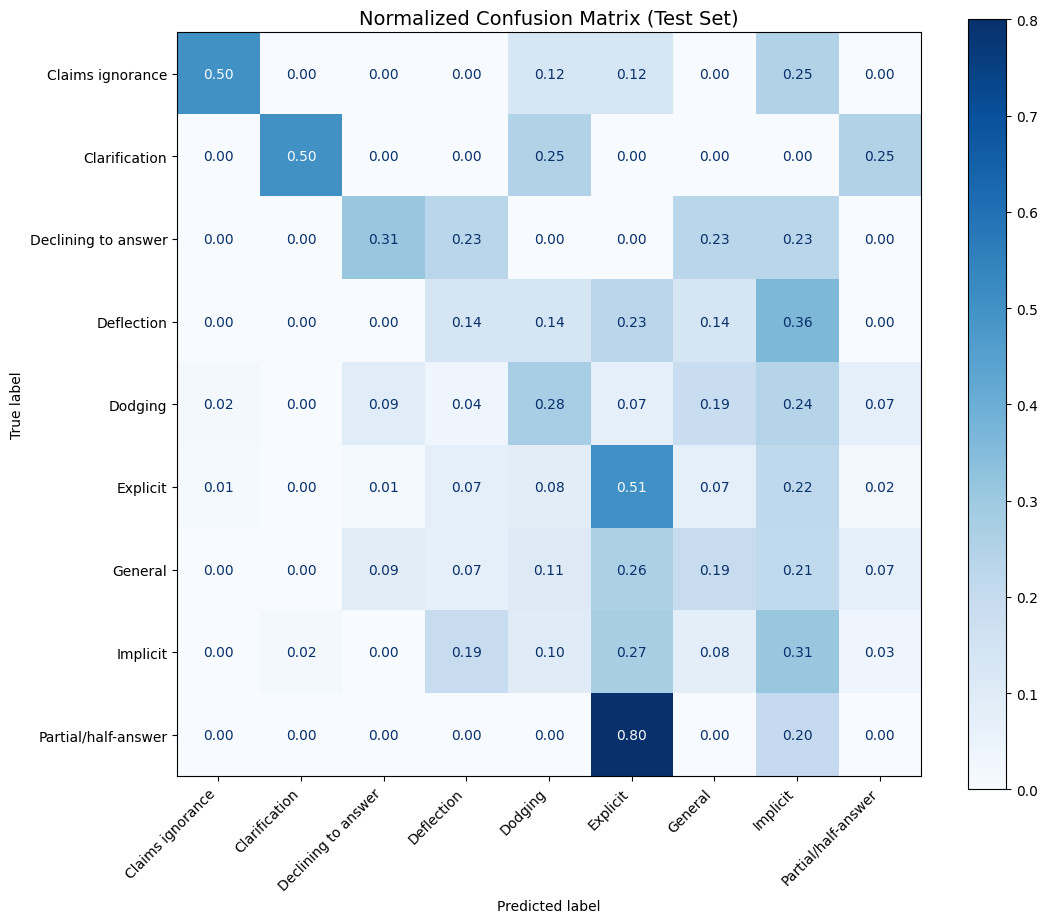

In [5]:
print("\n" + "="*80)
print("3. CONFUSION MATRIX")
print("="*80)

# Ahora ambos son ints, no debería fallar
print(classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred, labels=sorted(EVASION_LABELS.keys()), normalize='true')
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', values_format='.2f', ax=plt.gca())
plt.title("Normalized Confusion Matrix (Test Set)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

## Error Analysis 

### Qualitative Failure Examples

In [6]:
print("\n" + "="*80)
print("5. QUALITATIVE FAILURE ANALYSIS (Manual Inspection)")
print("="*80)

# Preparar DataFrame de Análisis
y_test = test_df['evasion_label']
analysis_df = test_df.copy()
analysis_df['true_label_id'] = y_test
analysis_df['pred_label_id'] = y_pred
analysis_df['true_label_txt'] = analysis_df['true_label_id'].map(EVASION_LABELS)
analysis_df['pred_label_txt'] = analysis_df['pred_label_id'].map(EVASION_LABELS)
analysis_df['is_error'] = analysis_df['true_label_id'] != analysis_df['pred_label_id']

errors_df = analysis_df[analysis_df['is_error']]
print(f"Total Errors: {len(errors_df)} / {len(test_df)}")

def print_example(row):
    print(f"\n[Error Example]")
    print(f"Q: {row['question']}")
    print(f"A: {row['interview_answer']}")
    print(f"TRUE: {row['true_label_txt']} | PRED: {row['pred_label_txt']}")
    print("-" * 50)

# 1. CLARIFICATION -> DODGING (Error masivo: 75% en matriz)
print("\n>>> TYPE A: 'Clarification' misclassified as 'Dodging'")
type_a = errors_df[(errors_df['true_label_txt'] == 'Clarification') & 
                   (errors_df['pred_label_txt'] == 'Dodging')]
if not type_a.empty:
    print_example(type_a.iloc[0])
else:
    print("No examples found for this specific error.")

# 2. IMPLICIT -> EXPLICIT (Error frecuente: 44% en matriz)
print("\n>>> TYPE B: 'Implicit' misclassified as 'Explicit'")
type_b = errors_df[(errors_df['true_label_txt'] == 'Implicit') & 
                   (errors_df['pred_label_txt'] == 'Explicit')]
if not type_b.empty:
    print_example(type_b.iloc[0])
else:
    print("No examples found for this specific error.")

# 3. EXPLICIT -> DODGING (Error común por longitud o retórica)
print("\n>>> TYPE C: 'Explicit' misclassified as 'Dodging'")
type_c = errors_df[(errors_df['true_label_txt'] == 'Explicit') & 
                   (errors_df['pred_label_txt'] == 'Dodging')]
if not type_c.empty:
    print_example(type_c.iloc[0])

# 4. PARTIAL/HALF-ANSWER -> EXPLICIT (Error de sutileza)
print("\n>>> TYPE D: 'Partial/half-answer' misclassified as 'Explicit'")
type_d = errors_df[(errors_df['true_label_txt'] == 'Partial/half-answer') & 
                   (errors_df['pred_label_txt'] == 'Explicit')]
if not type_d.empty:
    print_example(type_d.iloc[0])

# 5. RANDOM SAMPLE (Para variedad)
print("\n>>> TYPE E: Random Error Sample")
if not errors_df.empty:
    random_error = errors_df.sample(1, random_state=SEED).iloc[0]
    print_example(random_error)

print("\nAnalysis Complete.")


5. QUALITATIVE FAILURE ANALYSIS (Manual Inspection)
Total Errors: 208 / 308

>>> TYPE A: 'Clarification' misclassified as 'Dodging'

[Error Example]
Q: Reappointment of U.S. Attorney Patrick Fitzgerald
A: As a special prosecutor?
TRUE: Clarification | PRED: Dodging
--------------------------------------------------

>>> TYPE B: 'Implicit' misclassified as 'Explicit'

[Error Example]
Q: What makes this more than a piece of paper if you don't have the will of the international community to back it up?
A: Yes. No, listen—all the more reason why we need to help our friends and allies get the forces necessary to help the Lebanese forces keep the cessation of hostilities in place, intact. And that's why we're working with friends, with allies, with Security Council members, to make sure the force that is committed is robust and the rules of engagement are clear. And so it's an ongoing series of conversations and discussions, and hopefully, this will happen quite quickly.
TRUE: Implicit | PR

## Comparing Baseline vs Neural Models

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

print("\n" + "="*80)
print("6. COMPARING NEURAL MODEL VS BASELINE")
print("="*80)

# 1. Entrenar el Baseline rápidamente para tener sus predicciones
baseline_pipeline = make_pipeline(
    CountVectorizer(ngram_range=(1, 2), stop_words="english"),
    LogisticRegression(max_iter=1000, random_state=SEED)
)
baseline_pipeline.fit(train_df["sub_q_context"], train_df["evasion_label"])
baseline_preds = baseline_pipeline.predict(test_df["sub_q_context"])

# 2. Añadir las predicciones del baseline a nuestro DataFrame de análisis
analysis_df['baseline_pred_id'] = baseline_preds
analysis_df['baseline_pred_txt'] = analysis_df['baseline_pred_id'].map(EVASION_LABELS)

# 3. Filtrar: Ejemplos donde Neural (RoBERTa) ARREGLÓ el error del Baseline
fixed_errors = analysis_df[
    (analysis_df['baseline_pred_id'] != analysis_df['true_label_id']) &  # Baseline falló
    (analysis_df['pred_label_id'] == analysis_df['true_label_id'])       # RoBERTa acertó
]

print(f"\n>>> EXAMPLES WHERE NEURAL MODEL FIXED BASELINE ERRORS (Found: {len(fixed_errors)})")
# Mostrar hasta 5 ejemplos
for i, (_, row) in enumerate(fixed_errors.head(5).iterrows(), 1):
    print(f"\n[Fixed Example {i}]")
    print(f"Q: {row['question']}")
    print(f"A: {row['interview_answer']}")
    print(f"TRUE: {row['true_label_txt']} | BASELINE PRED: {row['baseline_pred_txt']} | NEURAL PRED: {row['pred_label_txt']}")
    print("-" * 50)

# 4. Filtrar: Ejemplos donde Neural (RoBERTa) INTRODUJO un nuevo error
new_errors = analysis_df[
    (analysis_df['baseline_pred_id'] == analysis_df['true_label_id']) &  # Baseline acertó
    (analysis_df['pred_label_id'] != analysis_df['true_label_id'])       # RoBERTa falló
]

print(f"\n>>> EXAMPLES WHERE NEURAL MODEL INTRODUCED NEW ERRORS (Found: {len(new_errors)})")
# Mostrar hasta 5 ejemplos
for i, (_, row) in enumerate(new_errors.head(5).iterrows(), 1):
    print(f"\n[New Error Example {i}]")
    print(f"Q: {row['question']}")
    print(f"A: {row['interview_answer']}")
    print(f"TRUE: {row['true_label_txt']} | BASELINE PRED: {row['baseline_pred_txt']} | NEURAL PRED: {row['pred_label_txt']}")
    print("-" * 50)


6. COMPARING NEURAL MODEL VS BASELINE

>>> EXAMPLES WHERE NEURAL MODEL FIXED BASELINE ERRORS (Found: 67)

[Fixed Example 1]
Q:  Inquiring about the status or information regarding the redline.
A: Well, the world has made it clear that these tests caused us to come together and work in the United Nations to send a clear message to the North Korean regime. We're bound up together with a common strategy to solve this issue peacefully through diplomatic means.Kevin [Kevin Corke, NBC News].
TRUE: Dodging | BASELINE PRED: Explicit | NEURAL PRED: Dodging
--------------------------------------------------

[Fixed Example 2]
Q: Will you invite them to the White House to negotiate on the jobs bill?
A: I think that anytime and anyplace that they are serious about working on putting people back to work, we'll be prepared to work with them. But we're not going to create a lot of theater that then results in them engaging in the usual political talking points, but don't result in action.People want

## Attention Weights


7. ATTENTION WEIGHTS VISUALIZATION


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Visualizing attention for text (True Label: Dodging):
 Inquiring about the status or information regarding the redline. [SEP] Well, the world has made it clear that these tests caused us to come together ...


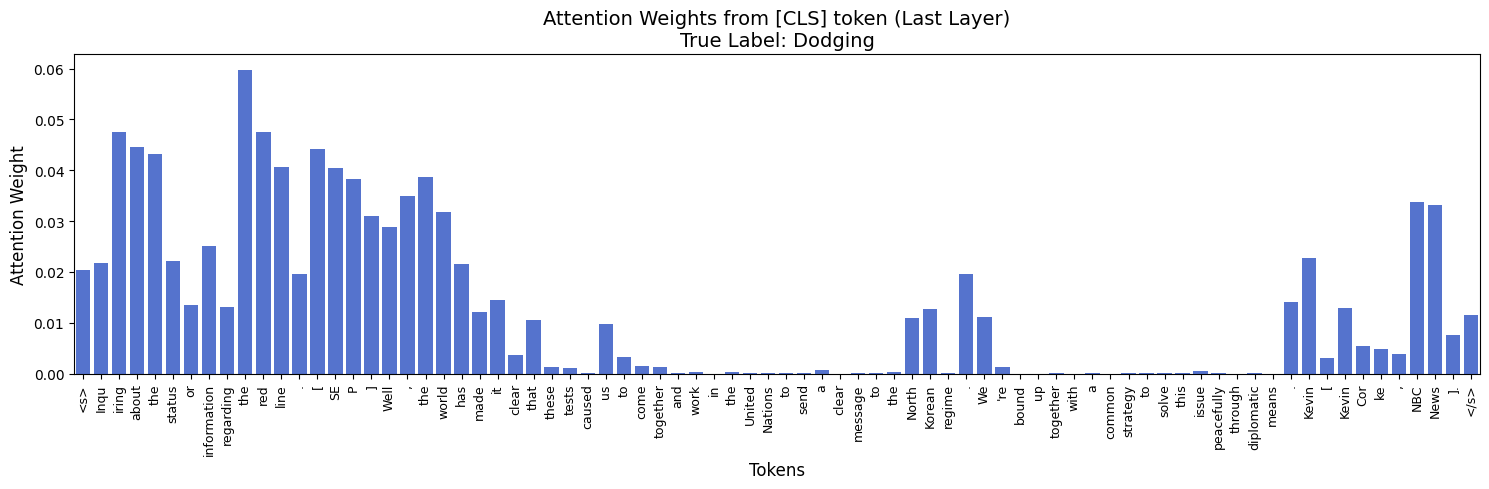


Saved: figures/attention_weights.png


In [10]:
import seaborn as sns
import copy

print("\n" + "="*80)
print("7. ATTENTION WEIGHTS VISUALIZATION")
print("="*80)

# --- CORRECCIÓN PARA EL ERROR DE SDPA ---
# Guardamos los pesos finetuneados temporalmente
fine_tuned_weights = copy.deepcopy(model.state_dict())

# Volvemos a instanciar la estructura del modelo en modo "eager" (para extraer atenciones)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, 
    num_labels=NUM_CLASSES, 
    attn_implementation="eager",
    output_attentions=True
).to(device)

# Le cargamos tus pesos entrenados al nuevo modelo
model.load_state_dict(fine_tuned_weights)
model.eval()
# ----------------------------------------

# Tomar un ejemplo interesante del test set (el primero que RoBERTa acertó pero el baseline falló)
if not fixed_errors.empty:
    sample_idx = fixed_errors.index[0]
else:
    sample_idx = 0  # Fallback al primer ejemplo si no hay errores arreglados

sample_text = test_df.loc[sample_idx, 'sub_q_context']
true_label = test_df.loc[sample_idx, 'evasion_label_txt']

print(f"Visualizing attention for text (True Label: {true_label}):\n{sample_text[:150]}...")

# Tokenizar el texto
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=128).to(device)

# Pasar por el modelo
with torch.no_grad():
    outputs = model(**inputs)

# Extraer las atenciones
# outputs.attentions es una tupla con las atenciones de cada capa.
# Tomamos la última capa: outputs.attentions[-1]
# Shape: (batch_size, num_heads, seq_len, seq_len)
last_layer_attention = outputs.attentions[-1][0] 

# Promediar la atención a través de todas las "heads" (cabezas de atención)
# Shape resultante: (seq_len, seq_len)
avg_attention = last_layer_attention.mean(dim=0)

# Obtener los pesos de atención desde el token [CLS] (índice 0) hacia el resto de tokens
cls_attention = avg_attention[0].cpu().numpy()

# Obtener los tokens como texto para el eje X
# Obtener los tokens como texto para el eje X
raw_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
# Limpiar el carácter 'Ġ' de RoBERTa para que el gráfico sea legible
clean_tokens = [t.replace('Ġ', '') for t in raw_tokens]

# Plotear usando Matplotlib y Seaborn
plt.figure(figsize=(15, 5))
sns.barplot(x=list(range(len(clean_tokens))), y=cls_attention, color="royalblue")
plt.xticks(ticks=list(range(len(clean_tokens))), labels=clean_tokens, rotation=90, fontsize=9)
plt.title(f"Attention Weights from [CLS] token (Last Layer)\nTrue Label: {true_label}", fontsize=14)
plt.xlabel("Tokens", fontsize=12)
plt.ylabel("Attention Weight", fontsize=12)
plt.tight_layout()
plt.savefig("figures/attention_weights.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: figures/attention_weights.png")